# Detekcja anomalii w obrazach mikroskopowych przy użyciu Autoenkodera

Celem projektu jest stworzenie systemu do automatycznego wykrywania anomalii w syntetycznych obrazach komórek. Wykorzystujemy metodę uczenia nienadzorowanego (unsupervised learning), w której model uczy się rekonstruować "zdrowe" obrazy.

**Koncepcja działania:**
1. Model trenowany jest wyłącznie na poprawnych danych.
2. Wysoki błąd rekonstrukcji (SSIM) dla nowych danych sygnalizuje anomalię.
3. Wyniki weryfikowane są testem statystycznym t-Studenta.

## Architektura Modelu: Splotowy Autoenkoder (CNN)

W tym notebooku wykorzystano tą samą sieć neuronową typu Autoenkoder, jednakże ze zmianą funkcji błędu. Składa się ona z dwóch części:
* **Enkoder:** Seria warstw konwolucyjnych (3 bloki redukujące wymiary), które kompresują obraz wejściowy $128 \times 128 \times 3$ do skompresowanej reprezentacji cech (latent space).
* **Dekoder:** Symetryczna struktura odtwarzająca obraz do oryginalnych wymiarów.

Jako funkcję błędu przyjęto `1 - SSIM`, a metryką detekcji anomalii jest indeks strukturalnego podobieństwa (SSIM).

## Scenariusze Eksperymentalne

Przeprowadzono serię testów sprawdzających wrażliwość modelu na różne typy defektów. Dla każdego przypadku porównujemy rozkład SSIM zdrowych komórek z anomaliami:

1.  **Zmiana skali:** Komórki o nienaturalnie dużym promieniu.
2.  **Zmiana koloru:** Anomalie w barwie jądra i cytoplazmy.
3.  **Zaburzony rozkład:** Zmiana algorytmu rozmieszczenia komórek (skupiska/klastry).
4.  **Deformacja kształtu:** Zastosowanie szumu Perlina do zniekształcenia krawędzi.
5.  **Anomalia złożona:** Połączenie wielu defektów jednocześnie.

## Weryfikacja Statystyczna (Test t-Studenta)

Aby potwierdzić, że wykryte różnice w błędzie rekonstrukcji (SSIM) są istotne i nie wynikają z losowego doboru próby ("szczęśliwego trafu"), zastosowano **test t-Studenta dla prób niezależnych** (z poprawką Welcha na nierówną wariancję).

* **Hipoteza $H_0$:** Średni błąd rekonstrukcji dla anomalii i normy jest taki sam.
* **Wartość $p < 0.05$:** Oznacza statystycznie istotne wykrycie anomalii przez model.

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0263 - val_loss: 0.0096
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0084 - val_loss: 0.0072
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0065 - val_loss: 0.0058
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0053 - val_loss: 0.0049
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0046 - val_loss: 0.0042
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039 - val_loss: 0.0035
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 10/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0024 - val_loss: 0.0024


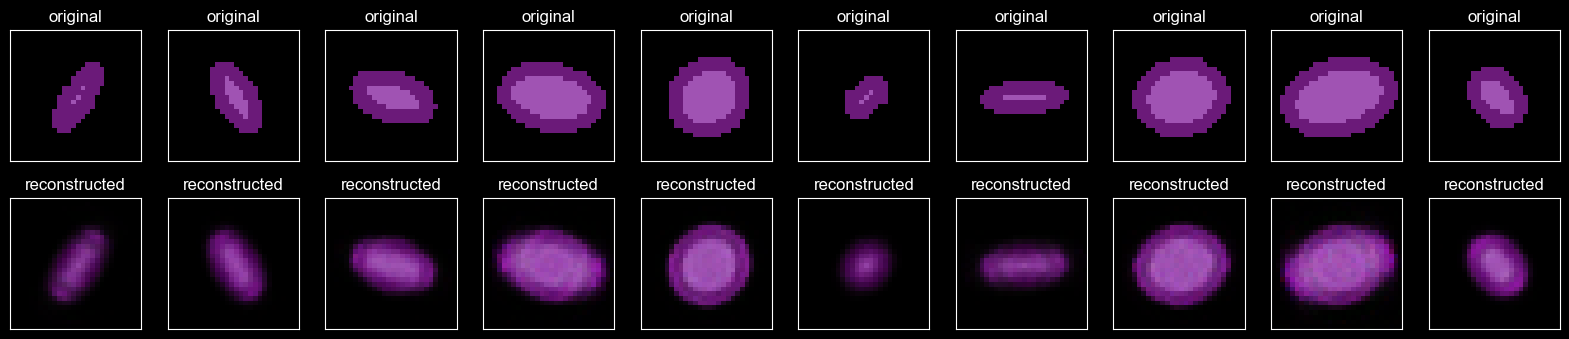

In [1]:


from builders.simple_generator import generate_batch
from src.builders.image_builder import ImageGenerator
from builders.config import GenerationConfig
from src.visualization.visualize_output import show_images
from src.functions.otsu_function import detect_anomaly_otsu_ssim

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import random
import keras
import numpy as np
from scipy.stats import ttest_ind
import tensorflow as tf
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv
from tensorflow.keras.callbacks import ReduceLROnPlateau

### Eksperyment pierwszy
Eksperyment, w którym definiujemy dwa zbiory z różnicami w wielkości komórek. Utworzone zostaną dwa zbiory z różnicą w rozmiarze komórek w zbiorze testowym. Ma to na celu sprawdzenie czy istnieje
różnica w SSIM.

Konfiguracja zbiorów

In [2]:
larger_cells_images_conf = GenerationConfig()
larger_cells_images_conf.axes.mean_x = 22
larger_cells_images_conf.axes.mean_y = 16
larger_cells_images_conf.axes.std_x = 6
larger_cells_images_conf.distribution.radius = 40

larger_cells = ImageGenerator(larger_cells_images_conf)

Utworzenie zbioru i sprawdzenie wyników

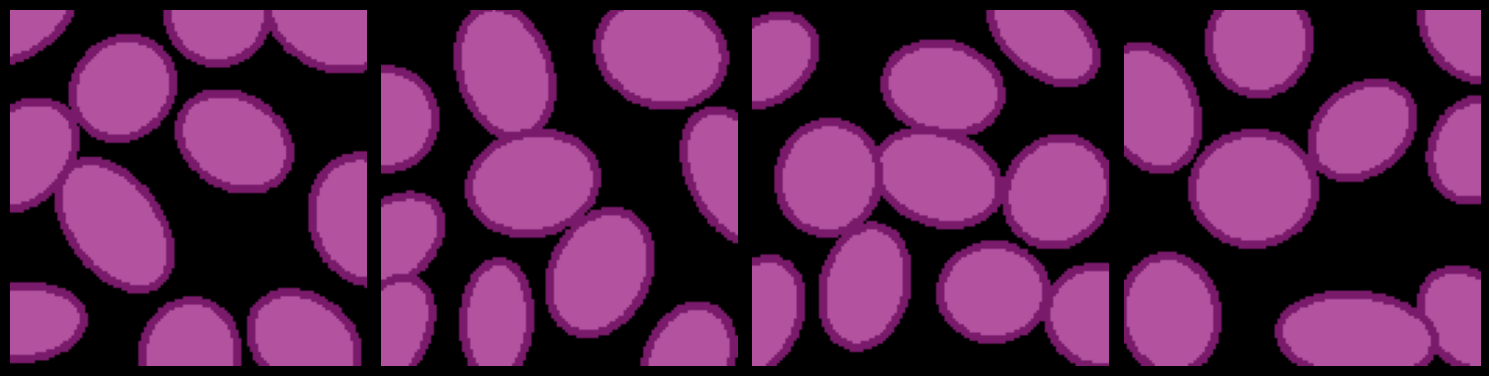

In [3]:
larger_cells_set = larger_cells.build_batch(2000)

show_images(larger_cells_set[:4])

### Eksperyment drugi
Eksperyment ma na celu sprawdzenie błędu SSIM w sytuacji gdy zmienia się kolor komórek.

Konfiguracja komórki

In [4]:
different_colors_conf = GenerationConfig()
different_colors_conf.nucleus.base_color = (134, 80, 34)
different_colors_conf.nucleus.border_color = (29, 40, 182)

different_colors_cells = ImageGenerator(different_colors_conf)

Utworzenie zbioru i sprawdzenie wyników

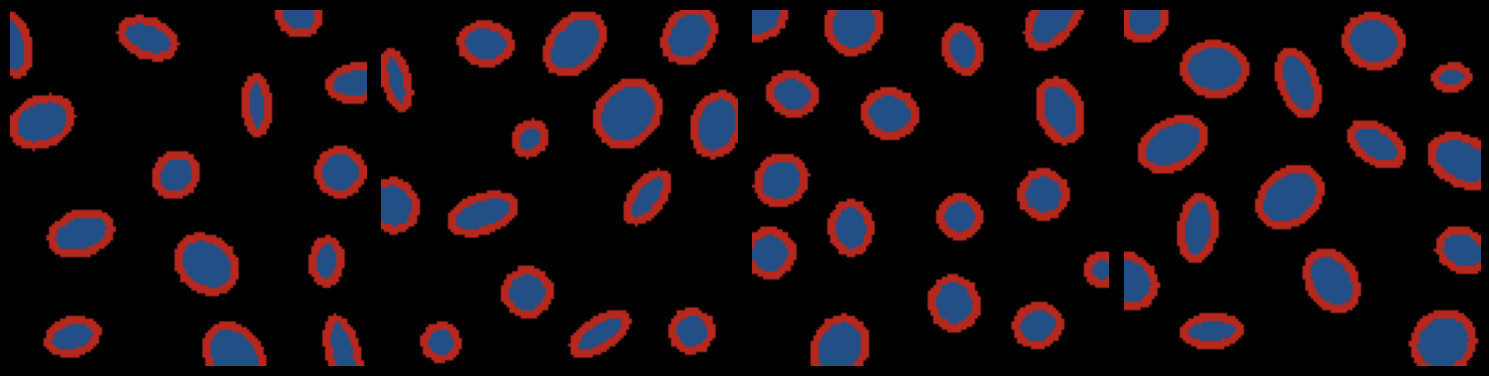

In [5]:
different_color_cells_set = different_colors_cells.build_batch(2000)

show_images(different_color_cells_set[:4])

### Eksperyment trzeci
W eksperymencie sprawdzone zostanie wpływ rozkładu komórek na błąd SSIM.

Konfiguracja komórki

In [6]:
distribution_conf = GenerationConfig()
distribution_conf.distribution.algorithm = "gaussian"

gaussian_dist_cells = ImageGenerator(distribution_conf)

Utworzenie zbioru i sprawdzenie wyników

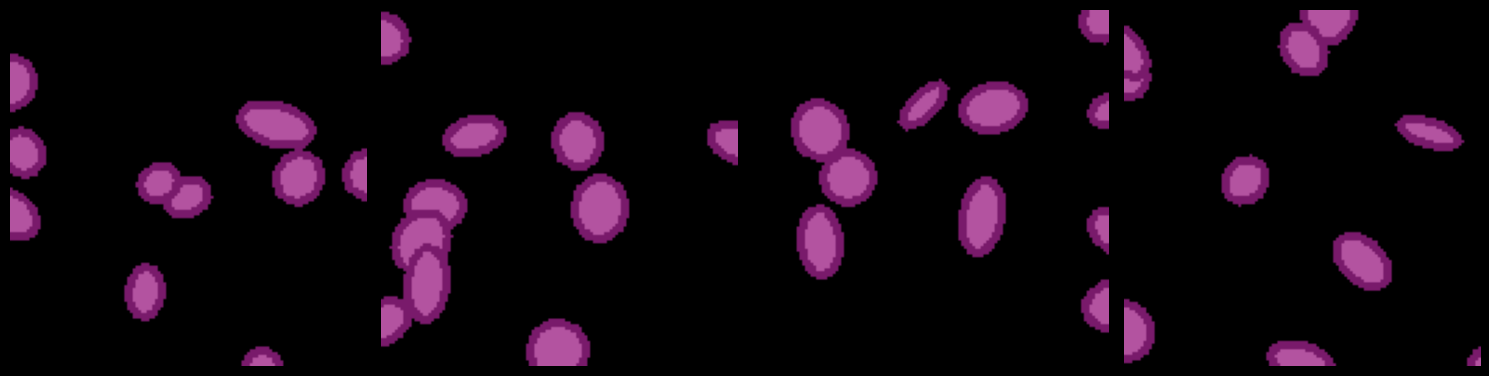

In [7]:
gaussian_dist_set = gaussian_dist_cells.build_batch(2000)

show_images(gaussian_dist_set[:4])

### Eksperyment czwarty
Sprawdzenie wpływu zniekształcenia kształtu komórek za pomocą szumu perlina na wynik SSIM.

In [8]:
perlin_noise_conf = (ImageGenerator()
                     .with_perlin_noise(True))

Utworzenie zbioru i sprawdzenie wyników.

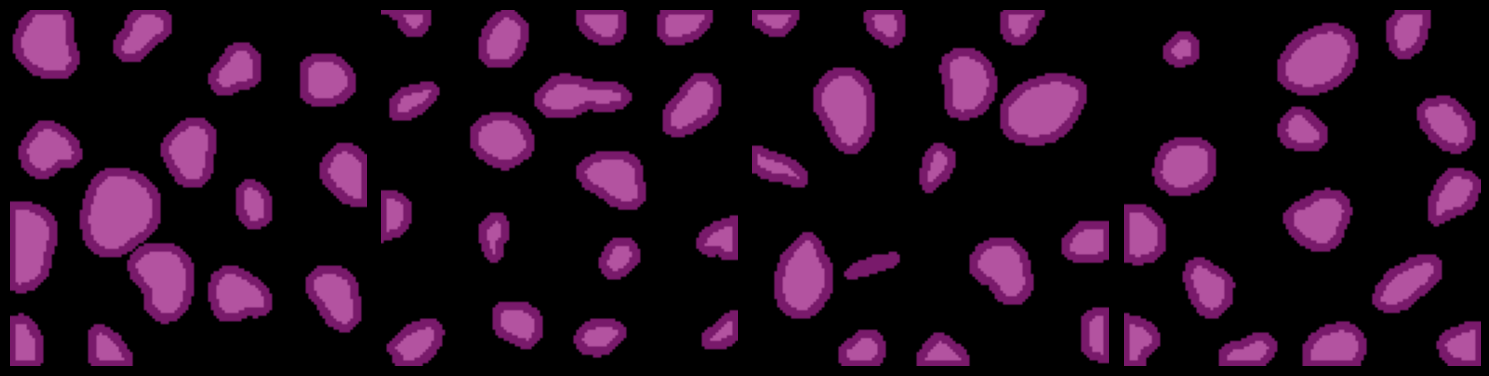

In [9]:
perlin_noise_set = perlin_noise_conf.build_batch(2000)

show_images(perlin_noise_set[:4])

### Eksperyment piąty

Połączenie wszystkich dotychczasowych eksperymentów.


In [10]:
various_conf = (ImageGenerator()
                .with_axes_config(16,18)
                .with_perlin_noise(True)
                .with_clustered_distribution(deviation=1)
                .with_cancer_cells(color=(23,190,40),
                                   border_color=(80,23,22)))

Utworzenie zbioru i sprawdzenie wyników.

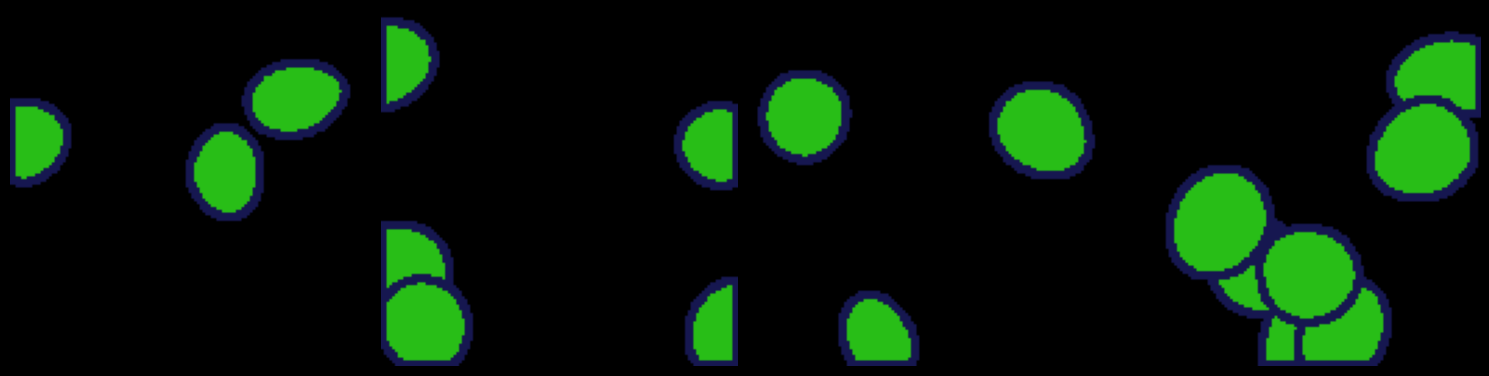

In [11]:
various_conf_set = various_conf.build_batch(2000)
show_images(various_conf_set[:4])

## Enkoder

Przygorowanie zbioru treningowego, walidacyjnego oraz testowego

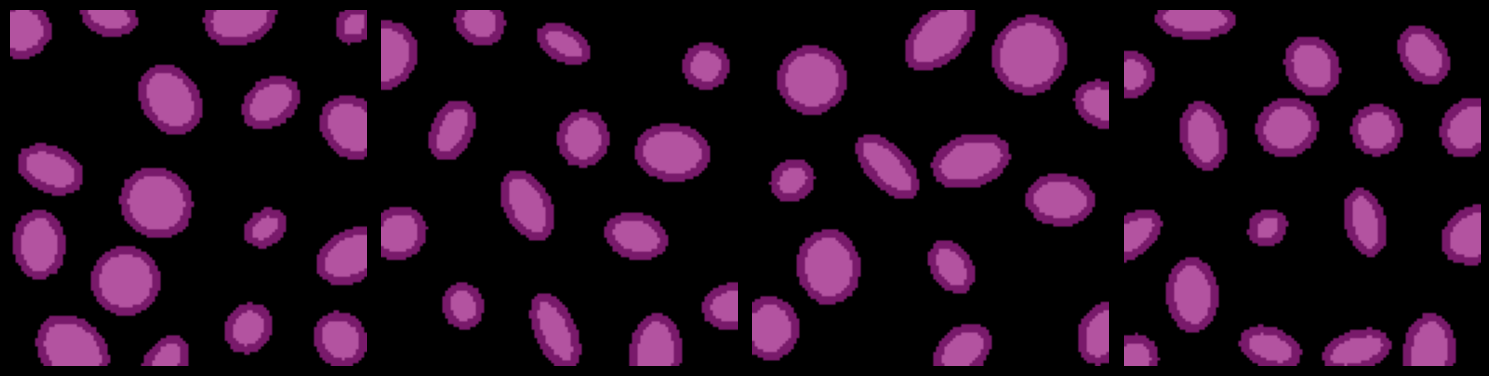

In [12]:
training_set = generate_batch(5000)

show_images(training_set[:4])

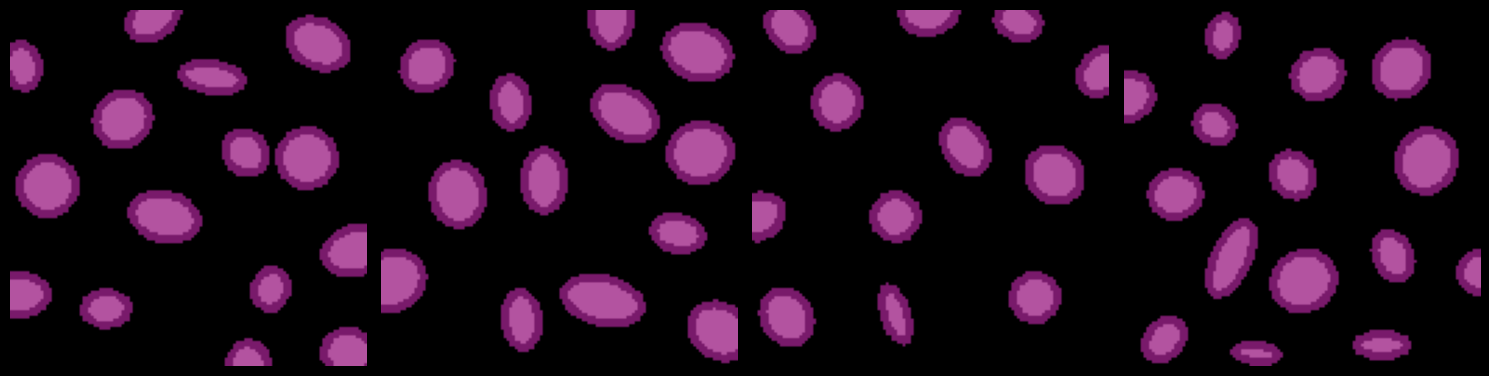

In [13]:
validation_set = generate_batch(1000)

show_images(validation_set[:4])

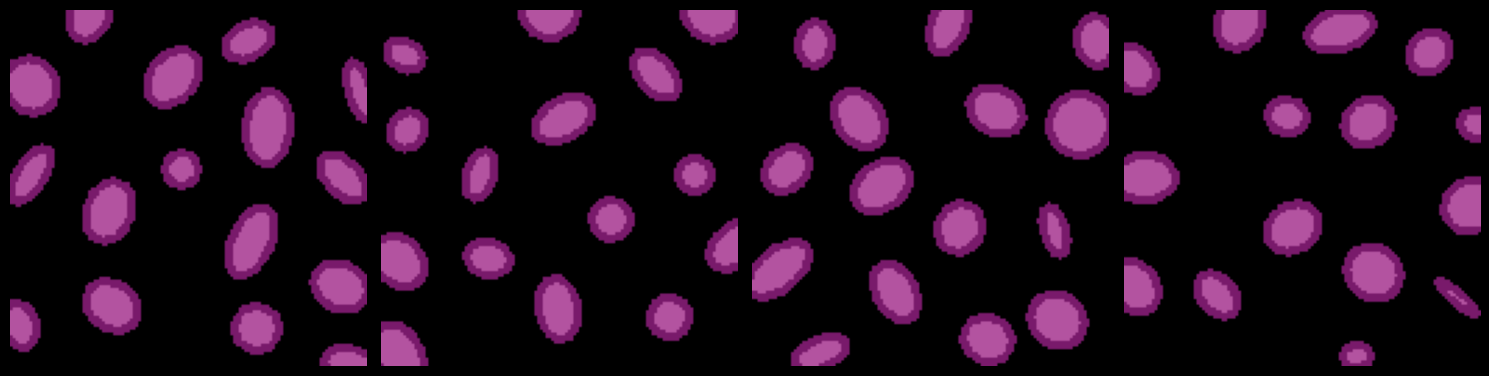

In [14]:
test_set = generate_batch(2000)

show_images(test_set[:4])

Przygotowanie danych dla enkodera

In [15]:
def preprocess(data_list):
    return np.array(data_list, dtype='float32') / 255.

In [16]:
x_test_data = preprocess(test_set)
x_val_data = preprocess(validation_set)
x_traning_data = preprocess(training_set)

In [17]:
def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

Inplementacja enkodera

In [18]:
enkoder = Encoder_conv()

#enkoder.compile(optimizer='adam', loss=ssim_loss, metrics=['mae', 'mse'])
enkoder.compile(optimizer='adam', loss=ssim_loss, metrics=['mae', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    min_delta=0.0001,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

history = enkoder.fit(
    x_traning_data, x_traning_data,
    epochs=100,
    shuffle=True,
    callbacks=[reduce_lr, early_stopping],
    validation_data=(x_val_data, x_val_data),
    verbose=1
)
print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - loss: 0.1857 - mae: 0.0583 - mse: 0.0216 - val_loss: 0.0539 - val_mae: 0.0186 - val_mse: 0.0024 - learning_rate: 0.0010
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - loss: 0.0432 - mae: 0.0149 - mse: 0.0018 - val_loss: 0.0388 - val_mae: 0.0140 - val_mse: 0.0017 - learning_rate: 0.0010
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step - loss: 0.0333 - mae: 0.0122 - mse: 0.0014 - val_loss: 0.0315 - val_mae: 0.0114 - val_mse: 0.0013 - learning_rate: 0.0010
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - loss: 0.0298 - mae: 0.0112 - mse: 0.0013 - val_loss: 0.0275 - val_mae: 0.0108 - val_mse: 0.0012 - learning_rate: 0.0010
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - loss: 0.0276 - mae: 0.0106 - mse: 0.0012 - val_loss: 0.0257 - val_mae: 0.0102 - val_mse: 0.0011 - learning_rate: 0.0010
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - loss: 0.0261 - mae: 0.0101 - mse: 0.0011 - val_loss:

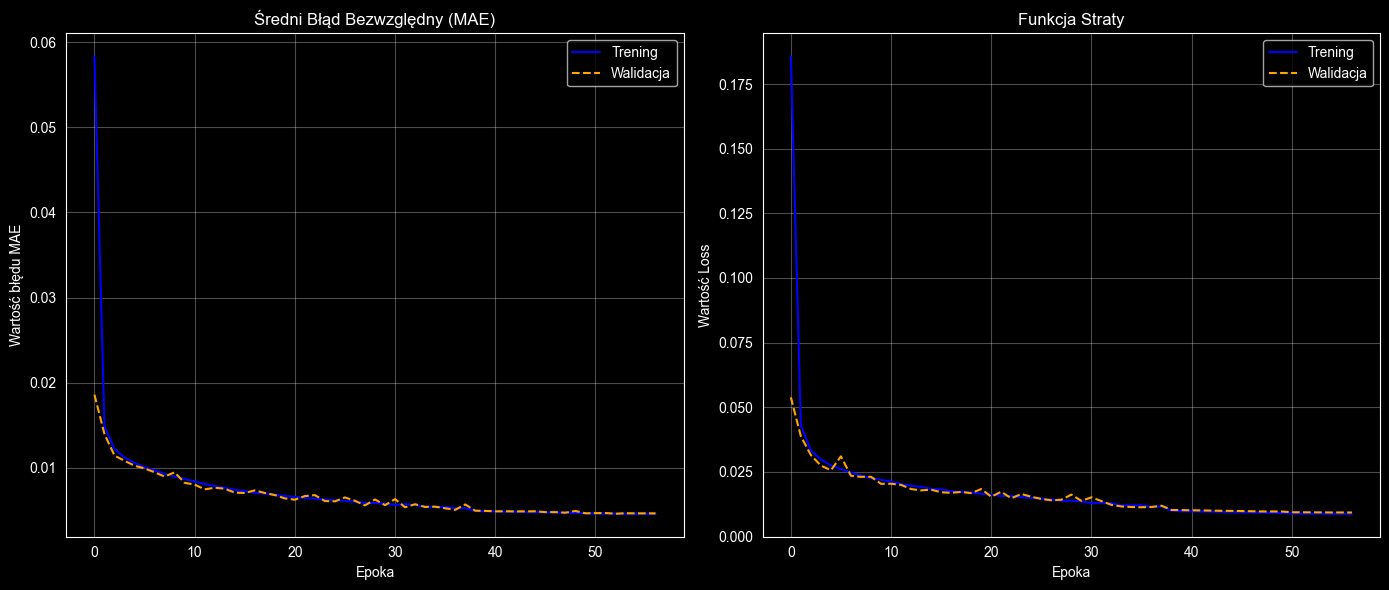

In [19]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='Trening', color='blue')
plt.plot(history.history['val_mae'], label='Walidacja', color='orange', linestyle='--')
plt.title('Średni Błąd Bezwzględny (MAE)')
plt.xlabel('Epoka')
plt.ylabel('Wartość błędu MAE')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Trening', color='blue')
plt.plot(history.history['val_loss'], label='Walidacja', color='orange', linestyle='--')
plt.title('Funkcja Straty')
plt.xlabel('Epoka')
plt.ylabel('Wartość Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step
SSIM Normal: 0.009362


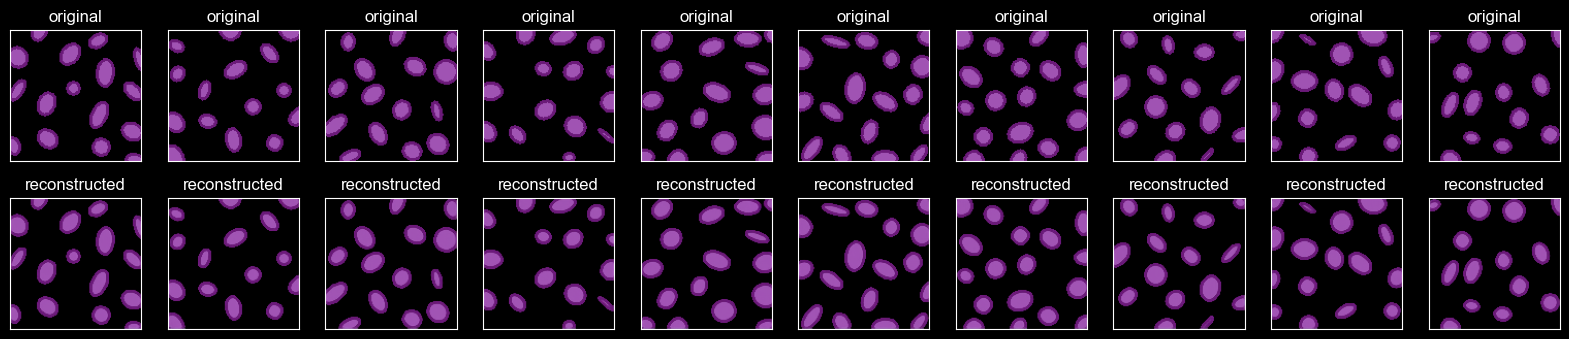

In [20]:
decoded_test = enkoder.predict(x_test_data)
ssim_test = enkoder.evaluate(x_test_data, x_test_data, verbose=0)[0]

print(f"SSIM Normal: {ssim_test:.6f}")

visualize_output(x_test_data, decoded_test, 10)

Wykres błędu SSIM

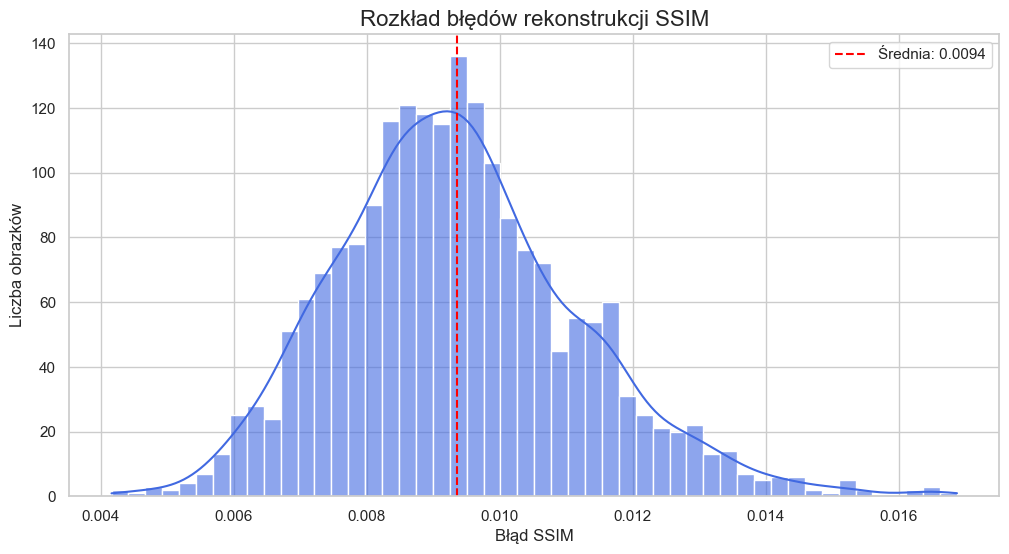

In [21]:
ssim_test_per_image = 1 - tf.image.ssim(x_test_data, decoded_test, max_val=1.0).numpy()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.histplot(ssim_test_per_image, bins=50, kde=True, color="royalblue", alpha=0.6)

mean_val = np.mean(ssim_test_per_image)
plt.axvline(mean_val, color='red', linestyle='--', label=f'Średnia: {mean_val:.4f}')

plt.title("Rozkład błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [22]:
test = [{'Eksperyment': 'SSIM test', 'Wynik': ssim_test}]

ssim_dataset = pd.DataFrame(test, columns=['Eksperyment', 'Wynik'])
ssim_dataset

,Eksperyment,Wynik
0,SSIM test,0.009362


### Wyniki eksperymentu pierwszego

Mean Reconstruction Error SSIM: 0.023896


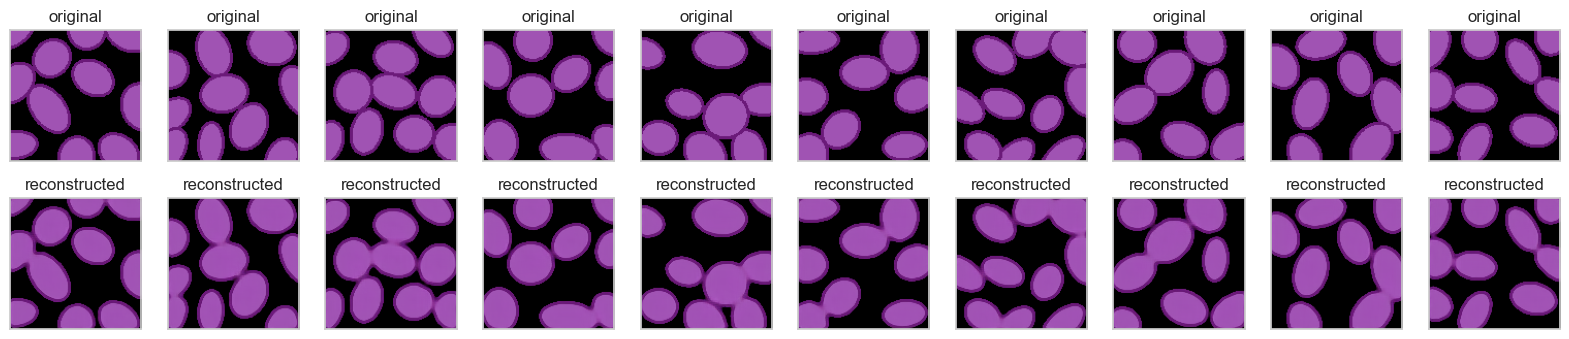

In [23]:
x_large_cells_data = preprocess(larger_cells_set)

decoded_large_cells = enkoder.predict(x_large_cells_data, verbose = 0)
ssim_large = enkoder.evaluate(x_large_cells_data, x_large_cells_data, verbose=0)[0]

print(f"Mean Reconstruction Error SSIM: {ssim_large:.6f}")

visualize_output(x_large_cells_data, decoded_large_cells, 10)

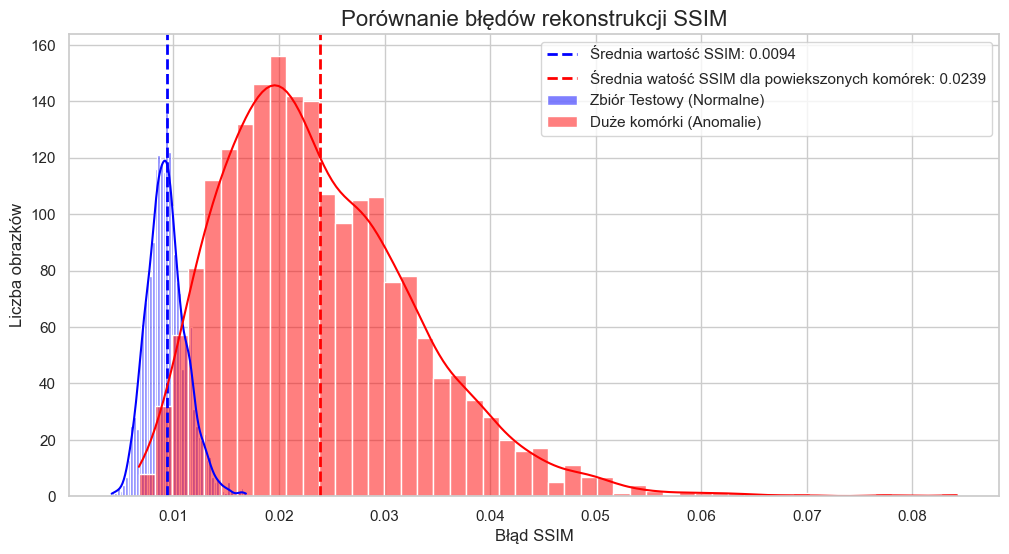

In [24]:
ssim_large_per_image = 1 - tf.image.ssim(x_large_cells_data, decoded_large_cells, max_val=1.0)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(ssim_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')
plt.axvline(x = np.mean(ssim_test_per_image), color='blue', linestyle='--',label = f'Średnia wartość SSIM: {np.mean(ssim_test_per_image):.4f}', linewidth=2)
sns.histplot(ssim_large_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Duże komórki (Anomalie)')
plt.axvline(np.mean(ssim_large_per_image), color= 'red', linestyle = '--', label = f'Średnia watość SSIM dla powiekszonych komórek: {np.mean(ssim_large_per_image):.4f}', linewidth=2)
plt.title("Porównanie błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

**Hipoteza zerowa**

Zakładamy, że wartość średniego błędu SSIM dla normalnych komórek jest taka sama jak dla anomalii. (Wariant pesymistyczny)

**Hipoteza alternatywna**

Średni błąd SSIM dla anomalii jest większy niż komórek normalnych

**Aby wyeliminować podejrzenie losowości w wynikach SSIM zastosowano test t-studenta dla błędu SSIM.**

Interpretacja:
* Jeżeli p_value jest mniejsze niż 0.05 oznacza to, że szansa na to, że wynik uzyskaliśmy przez losowe zbiegnięcie się danych jest mniejsza niż 0.0001% i jest praktycznie niemożliwa. Odrzucamy hipotezę o szczęściu w losowaniu obrazów i model działa.
* Jeżeli p_value jest większe od 0.05 oznacza to, że istnieje ryzyko, że różnica wynika z przypadku. Pesymistyczna hipoteza zerowa mogła mieć miejsce.

In [25]:
t_stat1, p_val1 = ttest_ind(ssim_large_per_image, ssim_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat1:.4f}")
print(f"P-value: {p_val1:.30f}")

Statystyka t: 68.3013
P-value: 0.000000000000000000000000000000


In [26]:
larger_cells = [{'Eksperyment': 'SSIM for larger cells', 'Wynik': ssim_large}]

ssim_dataset = pd.concat([ssim_dataset, pd.DataFrame(larger_cells)],ignore_index=True)
ssim_dataset

,Eksperyment,Wynik
0,SSIM test,0.009362
1,SSIM for larger cells,0.023896


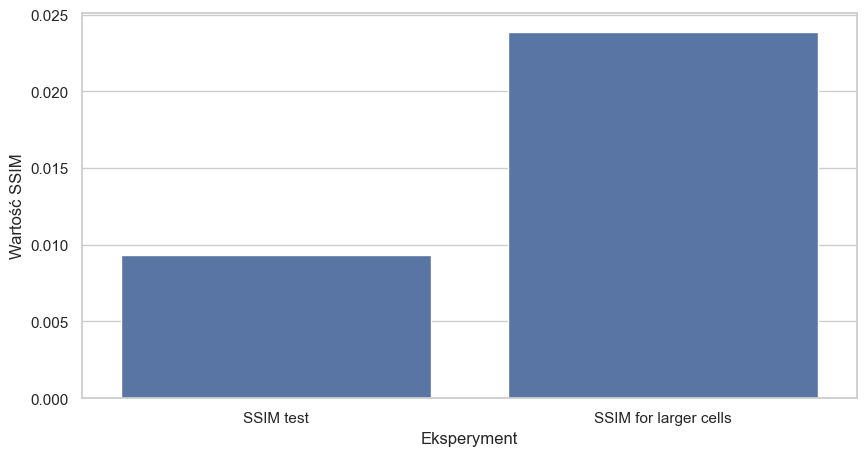

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(data=ssim_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość SSIM")
plt.show()

### Wyniki eksperymentu drugiego

Mean Reconstruction Error SSIM: 0.281438


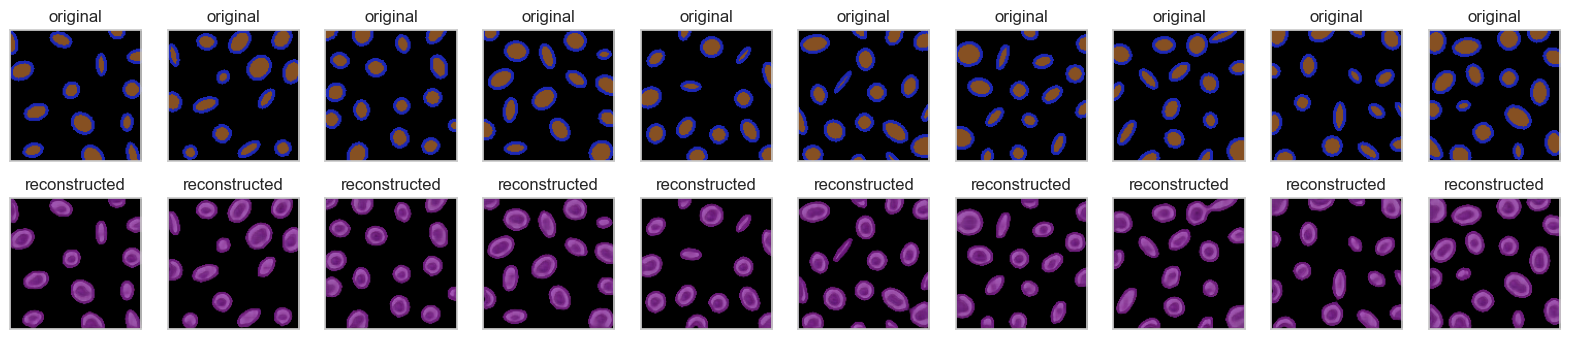

In [28]:
x_diff_color_cells_data = preprocess(different_color_cells_set)

decoded_diff_colors_cells = enkoder.predict(x_diff_color_cells_data,verbose = 0)
ssim_color = enkoder.evaluate(x_diff_color_cells_data, x_diff_color_cells_data, verbose=0)[0]

print(f"Mean Reconstruction Error SSIM: {ssim_color:.6f}")

visualize_output(x_diff_color_cells_data, decoded_diff_colors_cells, 10)

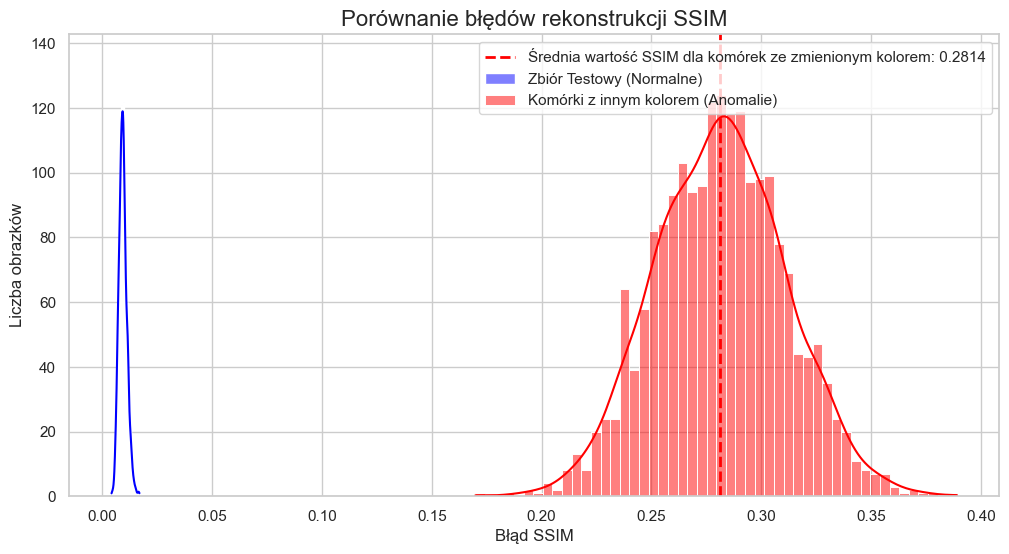

In [29]:
ssim_diff_color_per_image = 1 - tf.image.ssim(x_diff_color_cells_data, decoded_diff_colors_cells, max_val=1.0).numpy()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(ssim_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(ssim_diff_color_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Komórki z innym kolorem (Anomalie)')
plt.axvline(x = np.mean(ssim_diff_color_per_image), color='red', linestyle='--', linewidth=2, label = f'Średnia wartość SSIM dla komórek ze zmienionym kolorem: {np.mean(ssim_diff_color_per_image):.4f}')

plt.title("Porównanie błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [30]:
t_stat2, p_val2 = ttest_ind(ssim_diff_color_per_image, ssim_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat2:.4f}")
print(f"P-value: {p_val2:.30f}")

Statystyka t: 409.9706
P-value: 0.000000000000000000000000000000


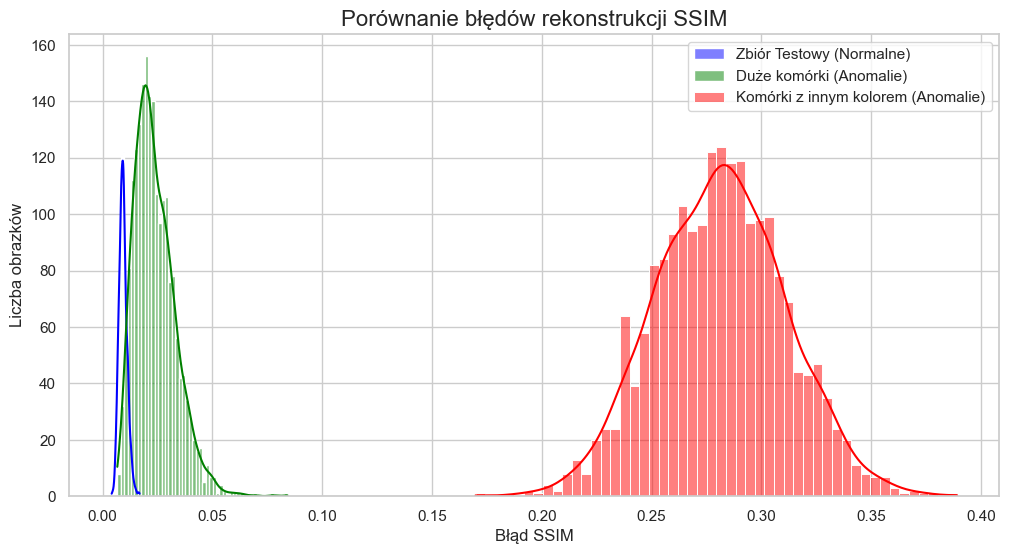

In [31]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(ssim_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')
sns.histplot(ssim_large_per_image, bins=50, kde=True,
             color='green', alpha=0.5, label='Duże komórki (Anomalie)')
sns.histplot(ssim_diff_color_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Komórki z innym kolorem (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [32]:
diff_color_cells = [{'Eksperyment': 'SSIM with different color', 'Wynik': ssim_color}]

ssim_dataset = pd.concat([ssim_dataset, pd.DataFrame(diff_color_cells)],ignore_index=True)
ssim_dataset

,Eksperyment,Wynik
0,SSIM test,0.009362
1,SSIM for larger cells,0.023896
2,SSIM with different color,0.281438


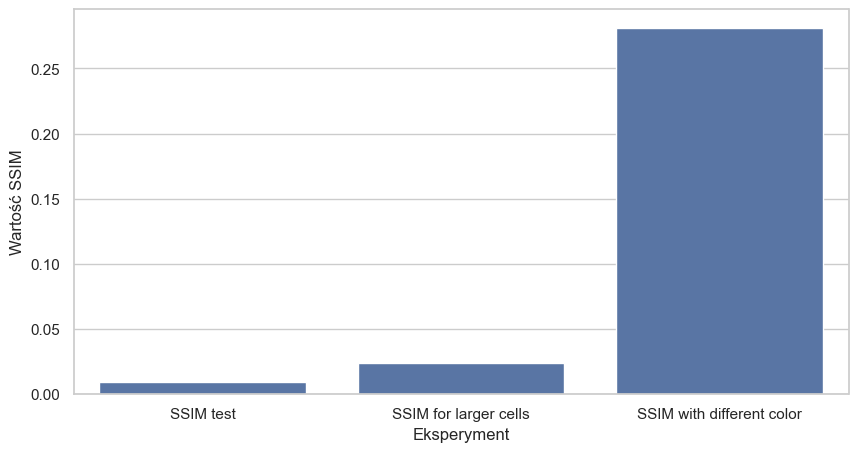

In [33]:
plt.figure(figsize=(10, 5))
sns.barplot(data=ssim_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość SSIM")
plt.show()

### Wyniki eksperymentu trzeciego

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step
Mean Reconstruction Error SSIM: 0.013655


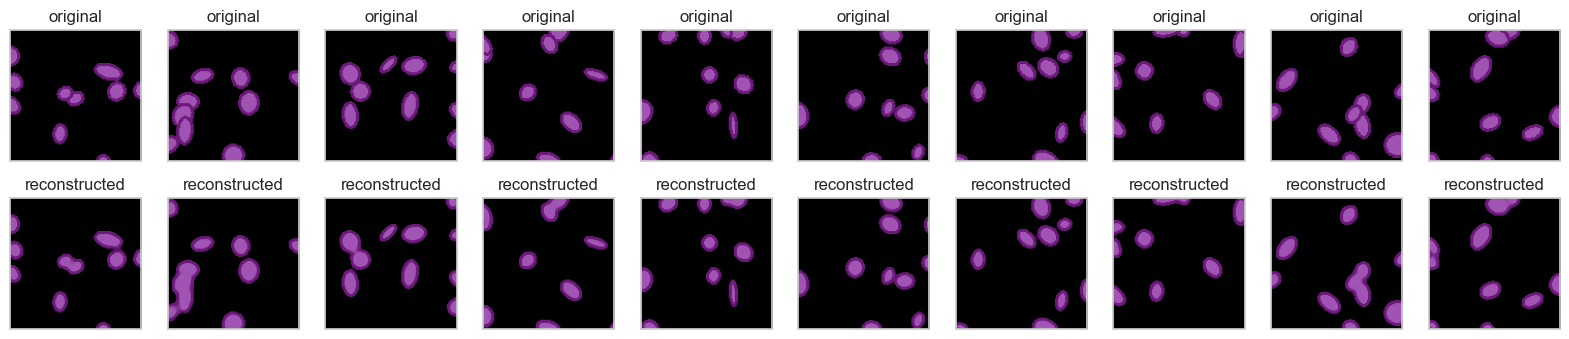

In [34]:
x_gaussian_dist_data = preprocess(gaussian_dist_set)

decoded_gaussian_dist_cells = enkoder.predict(x_gaussian_dist_data)
ssim_gaussian = enkoder.evaluate(x_gaussian_dist_data,x_gaussian_dist_data,verbose = 0)[0]

print(f"Mean Reconstruction Error SSIM: {ssim_gaussian:.6f}")

visualize_output(x_gaussian_dist_data, decoded_gaussian_dist_cells, 10)

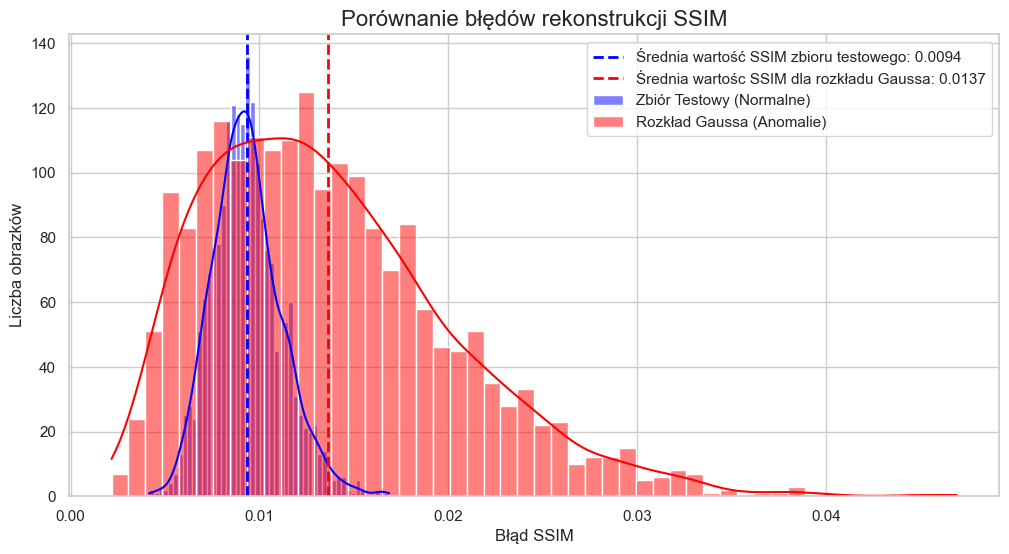

In [35]:
ssim_gaussian_per_image = 1 - tf.image.ssim(x_gaussian_dist_data, decoded_gaussian_dist_cells, max_val=1.0).numpy()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(ssim_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')
plt.axvline(np.mean(ssim_test_per_image), color= 'blue', linestyle='--', linewidth=2, label = f'Średnia wartość SSIM zbioru testowego: {np.mean(ssim_test_per_image):.4f}')
sns.histplot(ssim_gaussian_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Rozkład Gaussa (Anomalie)')
plt.axvline(np.mean(ssim_gaussian_per_image), color = 'red', linestyle = '--', linewidth = 2 , label = f'Średnia wartośc SSIM dla rozkładu Gaussa: {np.mean(ssim_gaussian_per_image):.4f}')
plt.title("Porównanie błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [36]:
t_stat3, p_val3 = ttest_ind(ssim_gaussian_per_image, ssim_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat3:.4f}")
print(f"P-value: {p_val3:.30f}")

Statystyka t: 28.3159
P-value: 0.000000000000000000000000000000


In [37]:
gaussian_dist = [{'Eksperyment': "SSIM with Gauss's distribution", 'Wynik': ssim_gaussian}]

ssim_dataset = pd.concat([ssim_dataset, pd.DataFrame(gaussian_dist)],ignore_index=True)
ssim_dataset

,Eksperyment,Wynik
0,SSIM test,0.009362
1,SSIM for larger cells,0.023896
2,SSIM with different color,0.281438
3,SSIM with Gauss's distribution,0.013655


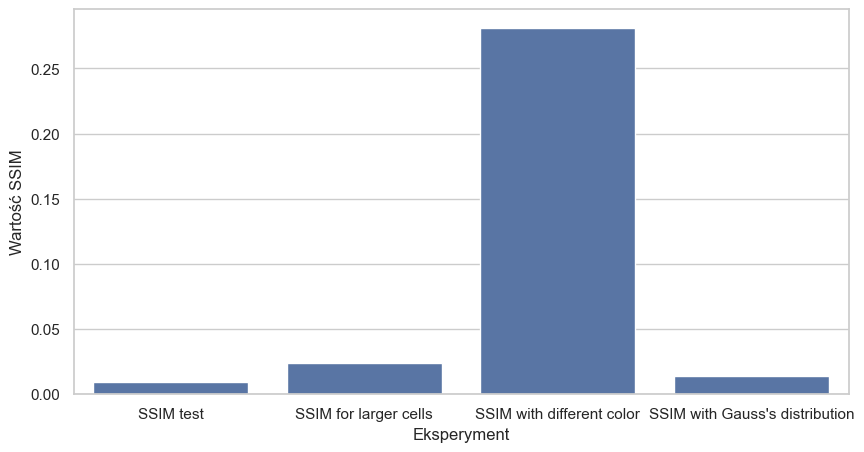

In [38]:
plt.figure(figsize=(10, 5))
sns.barplot(data=ssim_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość SSIM")
plt.show()

Wyniki eksperymentu czwartego

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step
Mean Reconstruction Error SSIM: 0.012815


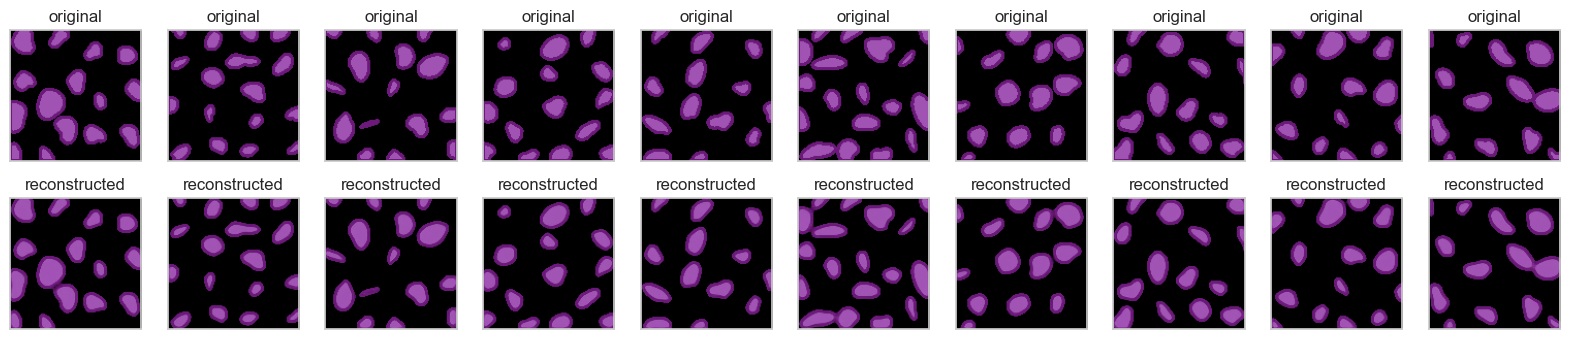

In [39]:
x_perlin_data = preprocess(perlin_noise_set)

decoded_perlin_noise_cells = enkoder.predict(x_perlin_data)
ssim_perlin = enkoder.evaluate(x_perlin_data,x_perlin_data,verbose = 0)[0]

print(f"Mean Reconstruction Error SSIM: {ssim_perlin:.6f}")

visualize_output(x_perlin_data, decoded_perlin_noise_cells, 10)

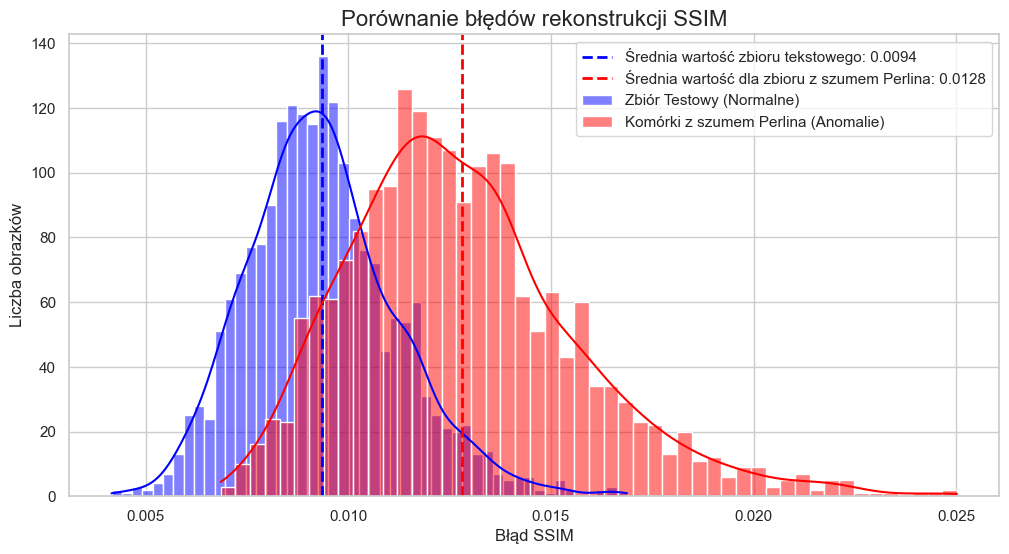

In [40]:
ssim_perlin_per_image = 1 - tf.image.ssim(x_perlin_data, decoded_perlin_noise_cells, max_val=1.0).numpy()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(ssim_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')
plt.axvline(np.mean(ssim_test_per_image),color = 'blue', linestyle = '--', linewidth = 2, label = f'Średnia wartość zbioru tekstowego: {np.mean(ssim_test_per_image):.4f}')
sns.histplot(ssim_perlin_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Komórki z szumem Perlina (Anomalie)')
plt.axvline(np.mean(ssim_perlin_per_image), linestyle = '--', color = 'red', linewidth = 2, label = f'Średnia wartość dla zbioru z szumem Perlina: {np.mean(ssim_perlin_per_image):.4f}')
plt.title("Porównanie błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [41]:
t_stat4, p_val4 = ttest_ind(ssim_perlin_per_image, ssim_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat4:.4f}")
print(f"P-value: {p_val4:.30f}")

Statystyka t: 45.7557
P-value: 0.000000000000000000000000000000


In [42]:
perlin_cells = [{'Eksperyment': "SSIM with Perlin Noise", 'Wynik': ssim_perlin}]

ssim_dataset = pd.concat([ssim_dataset, pd.DataFrame(perlin_cells)], ignore_index=True)
ssim_dataset

,Eksperyment,Wynik
0,SSIM test,0.009362
1,SSIM for larger cells,0.023896
2,SSIM with different color,0.281438
3,SSIM with Gauss's distribution,0.013655
4,SSIM with Perlin Noise,0.012815


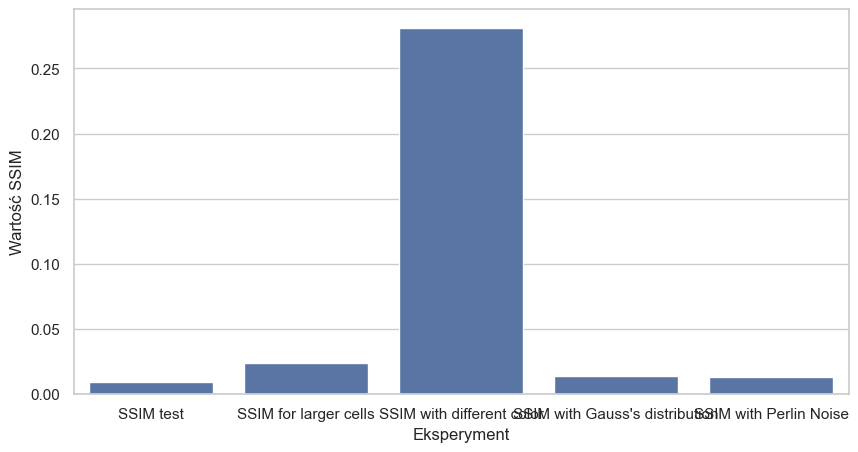

In [43]:
plt.figure(figsize=(10, 5))
sns.barplot(data=ssim_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość SSIM")
plt.show()

Wyniki eksperymentu piątego

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step
Mean Reconstruction Error SSIM: 0.266742


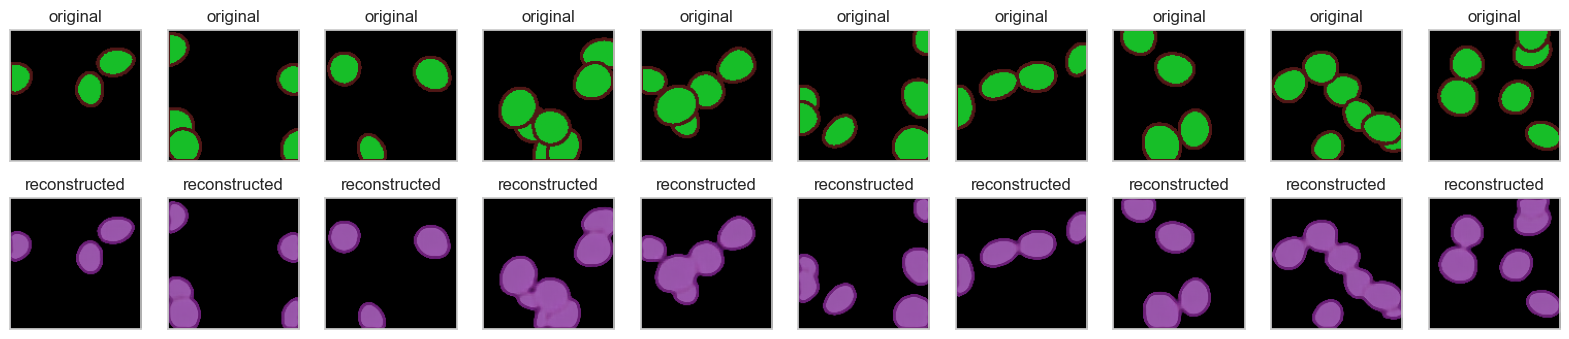

In [44]:
x_various_conf_data = preprocess(various_conf_set)

decoded_various_conf = enkoder.predict(x_various_conf_data)
ssim_various_conf = enkoder.evaluate(x_various_conf_data,x_various_conf_data,verbose = 0)[0]

print(f"Mean Reconstruction Error SSIM: {ssim_various_conf:.6f}")

visualize_output(x_various_conf_data, decoded_various_conf, 10)

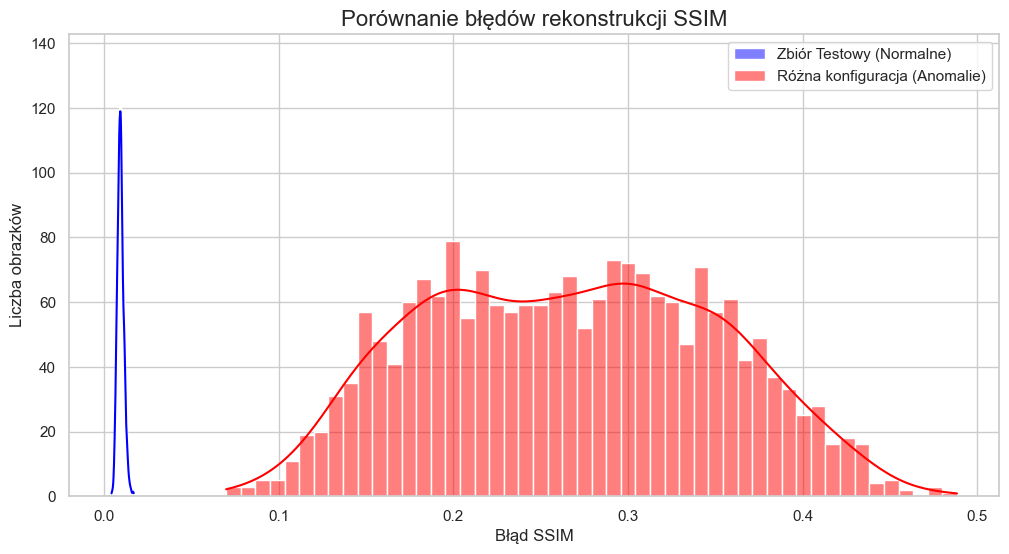

In [45]:
ssim_various_per_image = 1 - tf.image.ssim(x_various_conf_data, decoded_various_conf, max_val=1.0).numpy()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(ssim_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(ssim_various_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Różna konfiguracja (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji SSIM", fontsize=16)
plt.xlabel("Błąd SSIM", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [46]:
t_stat5, p_val5 = ttest_ind(ssim_various_per_image, ssim_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat5:.4f}")
print(f"P-value: {p_val5:.30f}")

Statystyka t: 138.4943
P-value: 0.000000000000000000000000000000


In [47]:
various_conf = [{'Eksperyment': "SSIM with various configuration", 'Wynik': 1 - ssim_various_conf}]

ssim_dataset = pd.concat([ssim_dataset, pd.DataFrame(various_conf)],ignore_index=True)
ssim_dataset

,Eksperyment,Wynik
0,SSIM test,0.009362
1,SSIM for larger cells,0.023896
2,SSIM with different color,0.281438
3,SSIM with Gauss's distribution,0.013655
4,SSIM with Perlin Noise,0.012815
5,SSIM with various configuration,0.733258


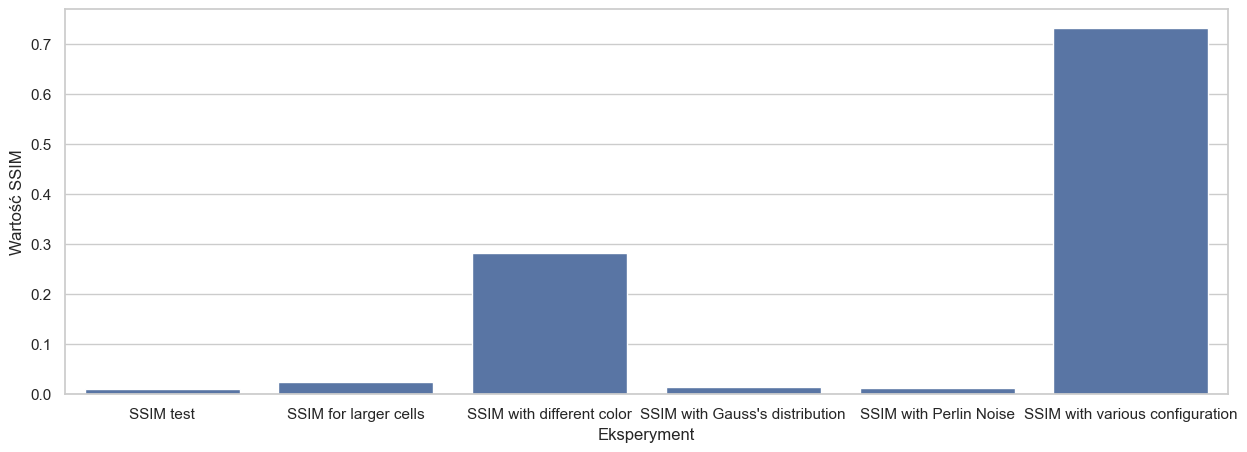

In [48]:
plt.figure(figsize=(15, 5))
sns.barplot(data=ssim_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość SSIM")
plt.show()

Implementacja metody Otsu do autmoatycznego wyznaczania progu wykrucia anomalii

In [49]:
otsu_thresholds = []

for i in range(len(x_perlin_data)):
    input_data = x_perlin_data[i]
    output_data = decoded_perlin_noise_cells[i]

    calculated_thereshold, anomaly_mask, error_map = detect_anomaly_otsu_ssim(input_data, output_data)
    otsu_thresholds.append([calculated_thereshold, anomaly_mask, error_map])

In [50]:
all_thresholds = [x[0] for x in otsu_thresholds]

In [51]:
print(f'średni próg: {np.mean(all_thresholds)}')
print(f'najmniejsza wartość progu: {np.min(all_thresholds)}')
print(f'największa wartość progu: {np.max(all_thresholds)}')
print(f'std: {np.std(all_thresholds)}')

średni próg: 47.312
najmniejsza wartość progu: 26.0
największa wartość progu: 73.0
std: 5.737565337318609


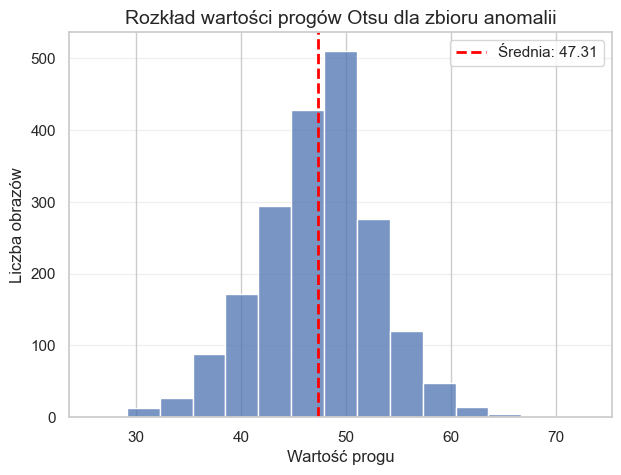

In [52]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
sns.histplot(x=all_thresholds, bins=15, kde=False)
plt.axvline(np.mean(all_thresholds), color='red', linestyle='--', linewidth=2, label=f'Średnia: {np.mean(all_thresholds):.2f}')

plt.title('Rozkład wartości progów Otsu (SSIM) dla zbioru anomalii', fontsize=14)
plt.xlabel('Wartość progu')
plt.ylabel('Liczba obrazów', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

In [53]:
idx = random.randint(0, len(otsu_thresholds)-1)

curr_org = x_perlin_data[idx]
curr_dec = decoded_perlin_noise_cells[idx]

idx_thresh = otsu_thresholds[idx][0]
idx_mask =  otsu_thresholds[idx][1]
idx_err = otsu_thresholds[idx][2]

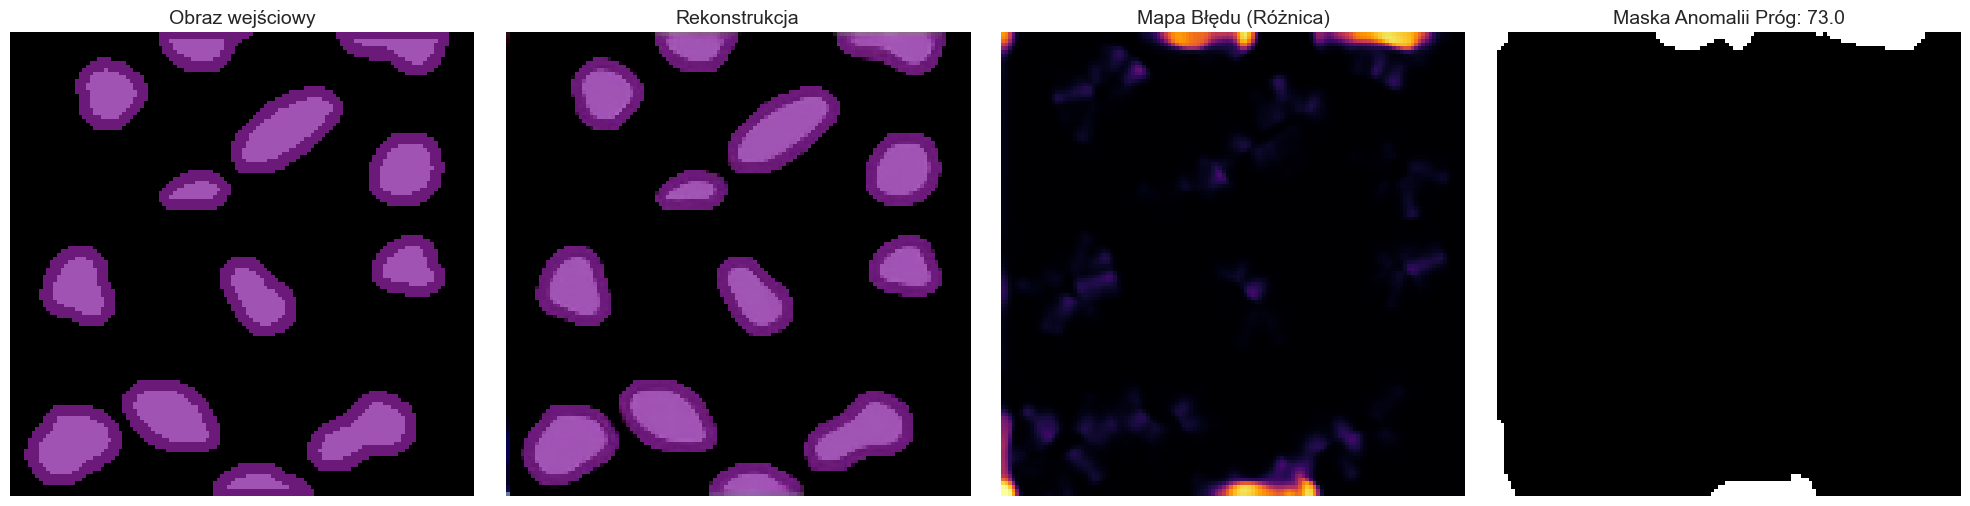

In [54]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 5))
plt.subplot(1,4,1)
plt.title("Obraz wejściowy", fontsize=14)
plt.imshow(curr_org)
plt.axis('off')


plt.subplot(1,4,2)
plt.title('Rekonstrukcja', fontsize=14)
plt.imshow(curr_dec)
plt.axis('off')


plt.subplot(1,4,3)
plt.imshow(idx_err, cmap='inferno')
plt.title("Mapa Błędu (1 - SSIM)", fontsize=14)
plt.axis('off')

plt.subplot(1,4,4)

plt.imshow(curr_org)
plt.imshow(idx_mask, cmap='gray', alpha=0.6)

plt.title(f"Maska Anomalii Próg: {idx_thresh:.1f}", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

In [55]:
df_healthy = pd.DataFrame({'SSIM': ssim_test_per_image, 'Typ': 'Zdrowa'})
df_cancer = pd.DataFrame({'SSIM': ssim_perlin_per_image, 'Typ': 'Anomalia'})
df_results = pd.concat([df_healthy,df_cancer], ignore_index=True)

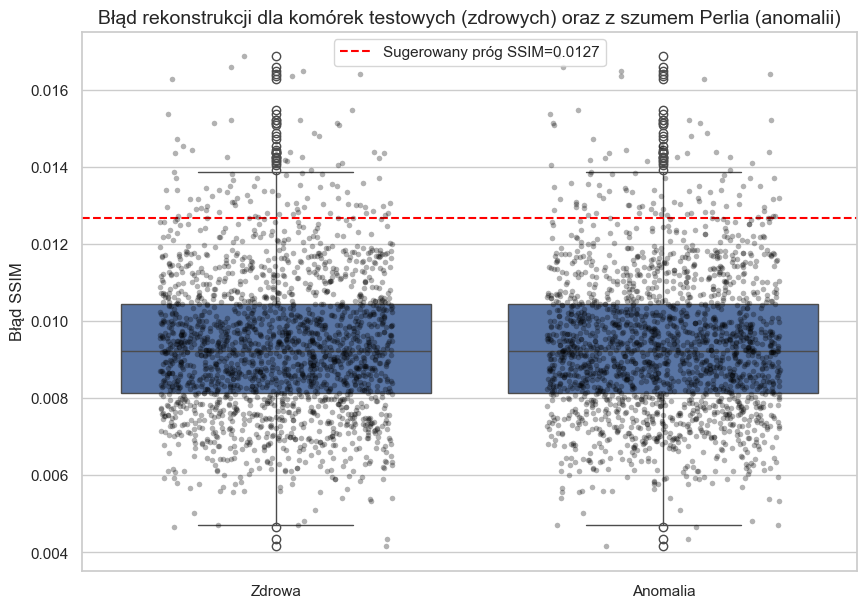

In [56]:
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(data=df_results, x='Typ', y='SSIM')

sns.stripplot(data=df_results, x='Typ', y='SSIM', color="black", alpha=0.3, jitter=0.3, size=4)

plt.title('Błąd rekonstrukcji dla komórek testowych (zdrowych) oraz z szumem Perlia (anomalii)', fontsize=14)
plt.ylabel('Błąd SSIM', fontsize=12)
plt.xlabel('')

threshold = np.percentile(ssim_test_per_image, 95)
plt.axhline(threshold, color='red', linestyle='--', label=f'Sugerowany próg SSIM={threshold:.4f}')
plt.legend()

plt.show()